In [1]:
!git status

On branch main
Your branch is ahead of 'origin/main' by 7 commits.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    5796f819-71ed-48ac-bd9a-135674afa291_2023-04-06_histograms.png
	deleted:    5796f819-71ed-48ac-bd9a-135674afa291_2023-04-06_mask.png
	deleted:    5796f819-71ed-48ac-bd9a-135674afa291_2023-04-06_visualization.png
	deleted:    91f8609a-c722-48bb-97e2-d647bf9e23fa_2023-04-06_analysis.png
	deleted:    91f8609a-c722-48bb-97e2-d647bf9e23fa_2023-04-06_histogram.png
	deleted:    91f8609a-c722-48bb-97e2-d647bf9e23fa_2023-04-06_mask.png
	deleted:    91f8609a-c722-48bb-97e2-d647bf9e23fa_2023-04-07_analysis.png
	deleted:    91f8609a-c722-48bb-97e2-d647bf9e23fa_2023-04-07_histogram.png
	deleted:    91f8609a-c722-48bb-97e2-d647bf9e23fa_2023-04-07_mask.png
	deleted:    HLS.L30.T11TPM.2024100T182420.v2.0.B05.t

In [2]:
!nvidia-smi  # Check for GPUs
!lscpu       # Check CPU info

Mon Sep  8 12:35:46 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.153.02             Driver Version: 570.153.02     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        On  |   00000000:41:00.0 Off |                  Off |
|  0%   33C    P8             30W /  480W |    1075MiB /  24564MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import geopandas as gpd
import pandas as pd

# Set pandas to display all columns without truncating them
pd.set_option('display.max_columns', None)

# The file path you provided
shapefile_path = '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'

print(f"Loading shapefile to display its header...")

try:
    # Load the shapefile
    gdf = gpd.read_file(shapefile_path)
    
    # Print the first 5 rows
    print("Shapefile loaded successfully. Here are the first 5 rows:")
    print(gdf.head())

except Exception as e:
    print(f"❌ An error occurred: {e}")

Loading shapefile to display its header...
Shapefile loaded successfully. Here are the first 5 rows:
   presence  Shape_Leng    Shape_Area observer_n   spp1          spp1_commo  \
0         1    0.000387  8.266529e-09       Ella   VEDU     Ventenata dubia   
1         1    0.000265  2.804779e-09      Simon  OTHER               OTHER   
2         1    0.000301  2.651498e-09      Simon   BRTE          Cheatgrass   
3         1    0.000493  1.059634e-08      Simon   PASM  Western wheatgrass   
4         1    0.000898  2.198568e-08      Simon   BRJA      Japanese Brome   

  spp1_statu  spp1_perce    spp1_pheno spp1_arran  spp2       spp2_commo  \
0          X        45.0         OTHER       None  VEDU  Ventenata dubia   
1         NA        45.0    Senescence       None  VEDU  Ventenata dubia   
2          X        30.0  Reproductive       None  VEDU  Ventenata dubia   
3          N        45.0     Seed Head    uniform  FORB            Sedge   
4          X        30.0  Panicle open    un


--- Loading and Validation for Plotting ---
✅ Columns successfully mapped.
✅ Percentage column validated.

--- Generating Data Distribution Plots ---


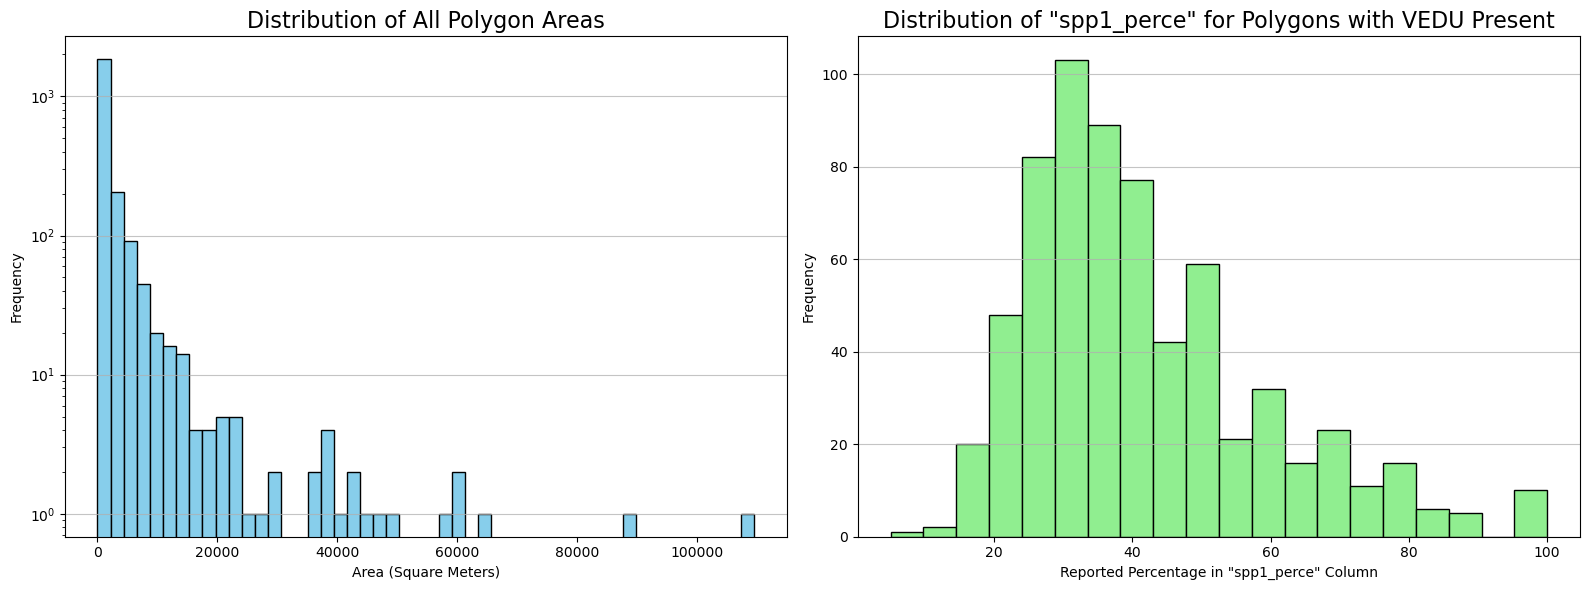

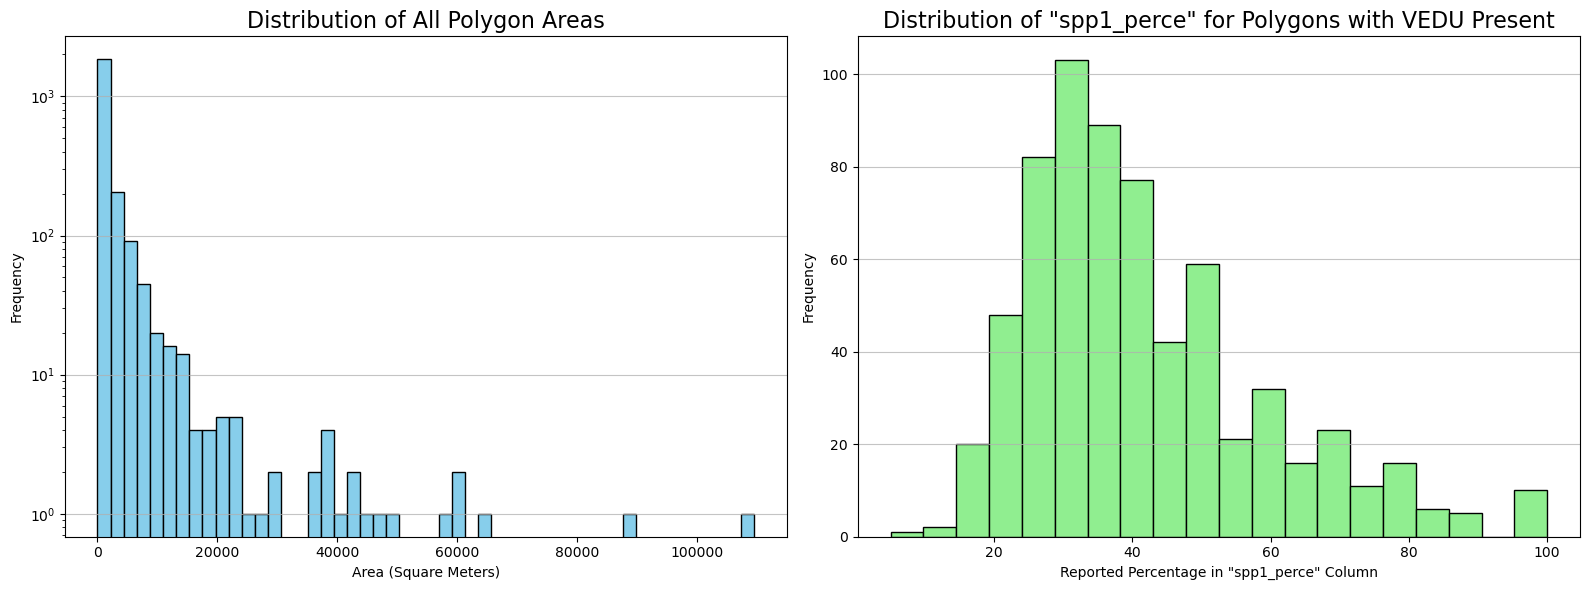

In [4]:
# --- BLOCK 1: EXPLORATORY DATA ANALYSIS (Corrected) ---
# Purpose: Load the raw data and visualize its distributions accurately.

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set pandas to display all columns without truncating them
pd.set_option('display.max_columns', None)


def load_and_validate_shapefile_for_plotting(filepath: str, column_map: dict) -> gpd.GeoDataFrame:
    """
    (Corrected for Plotting)
    Loads and prepares the shapefile, ensuring required columns exist and are numeric.
    """
    print(f"\n--- Loading and Validation for Plotting ---")
    gdf = gpd.read_file(filepath)
    
    # Check for required source columns before renaming
    source_cols = list(column_map.keys())
    missing = [col for col in source_cols if col not in gdf.columns]
    if missing:
        raise ValueError(f"Shapefile is missing expected columns: {missing}")

    # Rename the columns we will use
    gdf = gdf.rename(columns=column_map)
    print("✅ Columns successfully mapped.")
    
    # Ensure the main percentage column is numeric
    if not pd.api.types.is_numeric_dtype(gdf['primary_sp_percent']):
        gdf['primary_sp_percent'] = pd.to_numeric(gdf['primary_sp_percent'], errors='coerce').fillna(0)
    print("✅ Percentage column validated.")
    
    return gdf

def plot_data_distributions(gdf: gpd.GeoDataFrame, target_crs='EPSG:32611'):
    """
    (Corrected)
    Generates and returns a figure object with two histograms:
    1. Distribution of all polygon areas.
    2. True distribution of VEDU percentages, wherever VEDU is found.
    """
    print("\n--- Generating Data Distribution Plots ---")
    plot_gdf = gdf.copy()

    # --- 1. Area Histogram (No change needed here) ---
    plot_gdf['area_sqm'] = plot_gdf.to_crs(target_crs).geometry.area
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.hist(plot_gdf['area_sqm'], bins=50, color='skyblue', edgecolor='black')
    ax1.set_title('Distribution of All Polygon Areas', fontsize=16)
    ax1.set_xlabel('Area (Square Meters)')
    ax1.set_ylabel('Frequency')
    ax1.set_yscale('log')
    ax1.grid(axis='y', alpha=0.75)

    # --- 2. VEDU Percentage Histogram (New, more accurate logic) ---
    all_vedu_percentages = []
    
    # Unfortunately, the shapefile does not have separate percentage columns for spp2 and spp3.
    # The only percentage available is spp1_perce.
    # Therefore, we will plot the distribution of spp1_perce for all polygons where VEDU is present at all.
    vedu_present_gdf = plot_gdf[plot_gdf['is_vedu_present'] == 1]
    
    # We will use the 'primary_sp_percent' column for these rows.
    vedu_percentages = vedu_present_gdf['primary_sp_percent']

    ax2.hist(vedu_percentages, bins=20, color='lightgreen', edgecolor='black')
    ax2.set_title('Distribution of "spp1_perce" for Polygons with VEDU Present', fontsize=16)
    ax2.set_xlabel('Reported Percentage in "spp1_perce" Column')
    ax2.set_ylabel('Frequency')
    ax2.grid(axis='y', alpha=0.75)

    plt.tight_layout()
    return fig

# --- EXECUTION FOR PLOTTING ---

shapefile_path = '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'

# Based on your output, we create the correct map of column names.
# This map translates the file's column names to standard names our script can use.
column_name_map = {
    'presence': 'is_vedu_present',
    'spp1': 'primary_sp',
    'spp1_perce': 'primary_sp_percent',
    'spp2': 'spp2',
    'spp3': 'spp3',
    'global_id': 'global_id' 
}

# 1. Load the data using our corrected function and column map
initial_gdf = load_and_validate_shapefile_for_plotting(shapefile_path, column_name_map)

# 2. Generate the plot object
distribution_figure = plot_data_distributions(initial_gdf)

# 3. Display the plot directly in the notebook
distribution_figure

# LOAD SHAPEFILE FOR TRAINING


In [5]:
# =================================================================================
# --- DATA PROCESSING PIPELINE (Final Version with Corrected Control Filtering) ---
# =================================================================================

import pandas as pd
import geopandas as gpd
from sklearn.model_selection import train_test_split
import warnings

# Suppress specific warnings for a cleaner output
warnings.filterwarnings("ignore", message="The get_cmap function was deprecated", category=DeprecationWarning)
warnings.filterwarnings('ignore', 'GeoSeries.notna', UserWarning)

# --- HELPER FUNCTIONS (Unchanged) ---
def load_and_validate_shapefile(filepath: str, column_map: dict) -> gpd.GeoDataFrame:
    # ... (This function is correct and remains the same)
    print(f"\n--- Loading and Validation ---")
    gdf = gpd.read_file(filepath)
    print(f"✅ Shapefile loaded successfully. Found {len(gdf)} rows and {len(gdf.columns)} columns.")
    source_cols = list(column_map.keys())
    missing = [col for col in source_cols if col not in gdf.columns]
    if missing:
        core_missing = [c for c in missing if 'spp2' not in c and 'spp3' not in c]
        if core_missing: raise ValueError(f"Shapefile is missing critical columns: {core_missing}")
        else: print(f"NOTE: Optional columns not found and will be ignored: {missing}")
    gdf = gdf.rename(columns=column_map)
    print("✅ Columns successfully mapped.")
    for col in ['is_vedu_present', 'primary_sp_percent']:
        if not pd.api.types.is_numeric_dtype(gdf[col]):
            gdf[col] = pd.to_numeric(gdf[col], errors='coerce').fillna(0)
    print("✅ Key columns validated as numeric.")
    return gdf

def filter_vedu_polygons(gdf: gpd.GeoDataFrame, min_percent: float, min_area_sqm: float, target_crs='EPSG:32611') -> gpd.GeoDataFrame:
    # (This function is correct and remains the same)
    mask = (
        (gdf['is_vedu_present'] == 1) &
        ((gdf['primary_sp'] == 'VEDU') | (gdf.get('spp2') == 'VEDU') | (gdf.get('spp3') == 'VEDU')) &
        (gdf['primary_sp_percent'] > min_percent)
    )
    filtered_gdf = gdf[mask].copy()
    if filtered_gdf.empty: return filtered_gdf
    gdf_reprojected = filtered_gdf.to_crs(target_crs)
    gdf_reprojected['area_sqm'] = gdf_reprojected.geometry.area
    return gdf_reprojected[gdf_reprojected['area_sqm'] >= min_area_sqm].copy()

# --- MAIN DATA PREP FUNCTION (Final Corrected Version) ---
def generate_experimental_datasets_with_controls(
    filepath: str, column_map: dict, percent_thresholds: list, area_thresholds: list,
    target_crs='EPSG:32611', test_size=0.2, random_state=42
):
    base_gdf = load_and_validate_shapefile(filepath, column_map)
    
    master_train_gdf, final_test_set = train_test_split(
        base_gdf, test_size=test_size, stratify=base_gdf['is_vedu_present'], random_state=random_state
    )
    print("\n--- Master Sets Created ---")
    print(f"Master Training Set: {len(master_train_gdf)}")
    print(f"Final Held-Out Test Set: {len(final_test_set)}")

    print("\n--- Generating 25 Experimental Datasets ---")
    training_datasets = {}
    
    # Pre-calculate area for all training polygons once to be efficient
    master_train_gdf_reprojected = master_train_gdf.to_crs(target_crs)
    master_train_gdf_reprojected['area_sqm'] = master_train_gdf_reprojected.geometry.area

    for percent in percent_thresholds:
        for area in area_thresholds:
            experiment_name = f"percent_{percent}_area_{area}"
            print(f"\n>> Processing Experiment: {experiment_name}")
            
            # 1. Filter VEDU polygons from the master training set based on BOTH criteria
            vedu_mask = (
                (master_train_gdf_reprojected['is_vedu_present'] == 1) &
                ((master_train_gdf_reprojected['primary_sp'] == 'VEDU') | 
                 (master_train_gdf_reprojected.get('spp2') == 'VEDU') | 
                 (master_train_gdf_reprojected.get('spp3') == 'VEDU')) &
                (master_train_gdf_reprojected['primary_sp_percent'] > percent) &
                (master_train_gdf_reprojected['area_sqm'] >= area)
            )
            vedu_subset = master_train_gdf_reprojected[vedu_mask]
            
            # 2. Filter CONTROL polygons from the master training set based on AREA ONLY
            control_mask = (
                (master_train_gdf_reprojected['is_vedu_present'] == 0) &
                (master_train_gdf_reprojected['area_sqm'] >= area)
            )
            control_subset = master_train_gdf_reprojected[control_mask]

            print(f"  - Found {len(vedu_subset)} VEDU polygons and {len(control_subset)} Control polygons meeting criteria.")
            
            # 3. Combine the two correctly filtered subsets
            full_experiment_gdf = pd.concat([vedu_subset, control_subset], ignore_index=True)
            print(f"  - ✅ Total samples for this experiment: {len(full_experiment_gdf)}")
            
            training_datasets[experiment_name] = full_experiment_gdf
            
    print("\n\n✅✅✅ DATA PREPARATION PIPELINE COMPLETED SUCCESSFULLY ✅✅✅")
    return training_datasets, final_test_set

# ... (The rest of the script, including the EXECUTION block, can remain the same)


# =================================================================================
# --- CONFIGURATION AND EXECUTION ---
# =================================================================================
percent_variations = [10, 25, 50, 66.6, 75]
area_variations = [100, 250, 500, 750, 900]
shapefile_path = '/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp'
column_name_map = {
    'presence': 'is_vedu_present', 'spp1': 'primary_sp', 'spp1_perce': 'primary_sp_percent',
    'spp2': 'spp2', 'spp3': 'spp3', 'global_id': 'global_id' 
}

# Run the pipeline
experimental_sets, final_test_set = generate_experimental_datasets_with_controls(
    filepath=shapefile_path,
    column_map=column_name_map,
    percent_thresholds=percent_variations,
    area_thresholds=area_variations
)


--- Loading and Validation ---
✅ Shapefile loaded successfully. Found 2287 rows and 24 columns.
✅ Columns successfully mapped.
✅ Key columns validated as numeric.

--- Master Sets Created ---
Master Training Set: 1829
Final Held-Out Test Set: 458

--- Generating 25 Experimental Datasets ---

>> Processing Experiment: percent_10_area_100
  - Found 367 VEDU polygons and 1248 Control polygons meeting criteria.
  - ✅ Total samples for this experiment: 1615

>> Processing Experiment: percent_10_area_250
  - Found 285 VEDU polygons and 1089 Control polygons meeting criteria.
  - ✅ Total samples for this experiment: 1374

>> Processing Experiment: percent_10_area_500
  - Found 200 VEDU polygons and 858 Control polygons meeting criteria.
  - ✅ Total samples for this experiment: 1058

>> Processing Experiment: percent_10_area_750
  - Found 164 VEDU polygons and 668 Control polygons meeting criteria.
  - ✅ Total samples for this experiment: 832

>> Processing Experiment: percent_10_area_900
  -


--- Generating Final Comparison Plots ---
✅ Color map created for VEDU categories.
Generating detailed categorical heatmap...
Generating geospatial map with all sites...
Generating geospatial map with VEDU sites only...
✅ All three figures created successfully.

Displaying Detailed Categorical Heatmap (Legend):


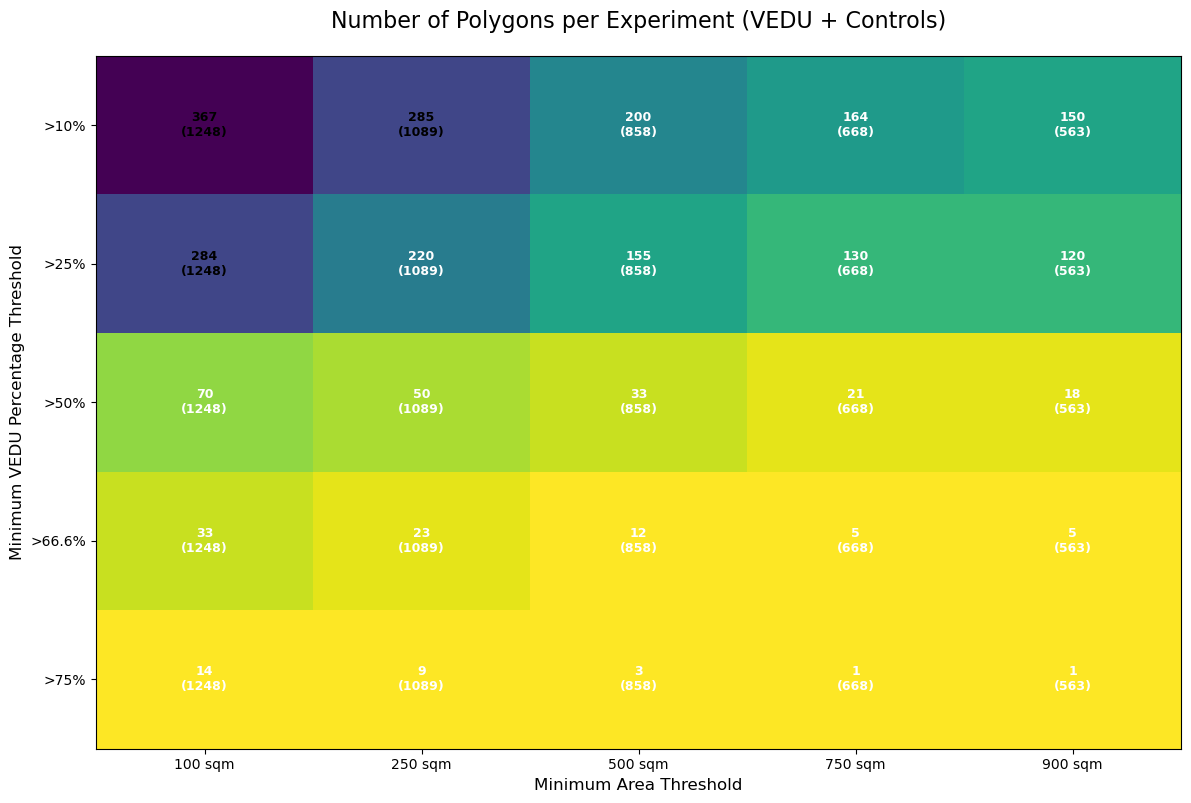


Displaying Geospatial Map (VEDU Sites Colored, Controls in Gray):


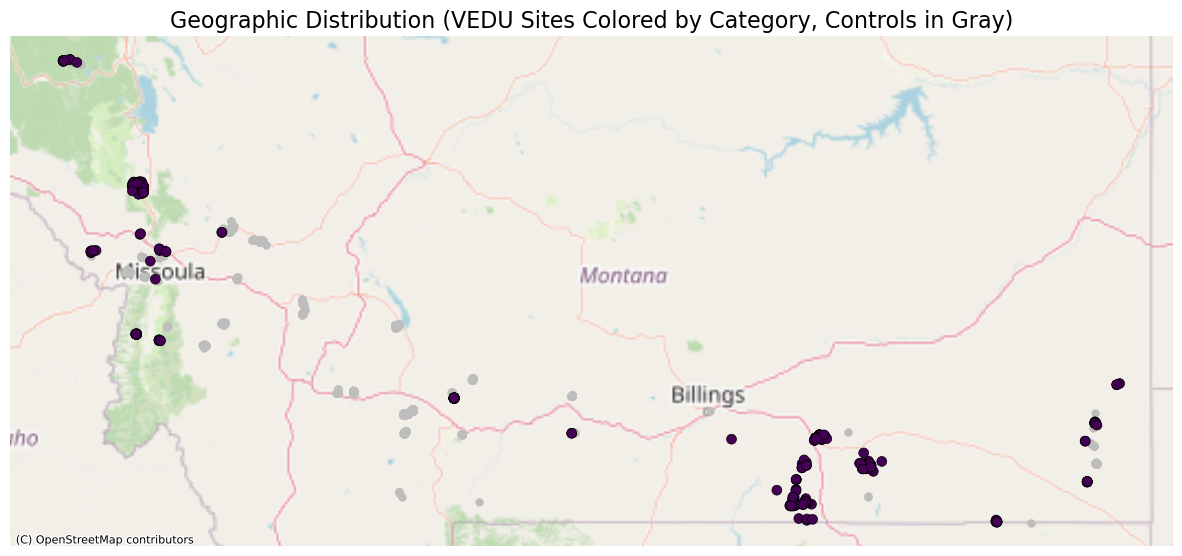


Displaying Geospatial Map (VEDU Sites Only):


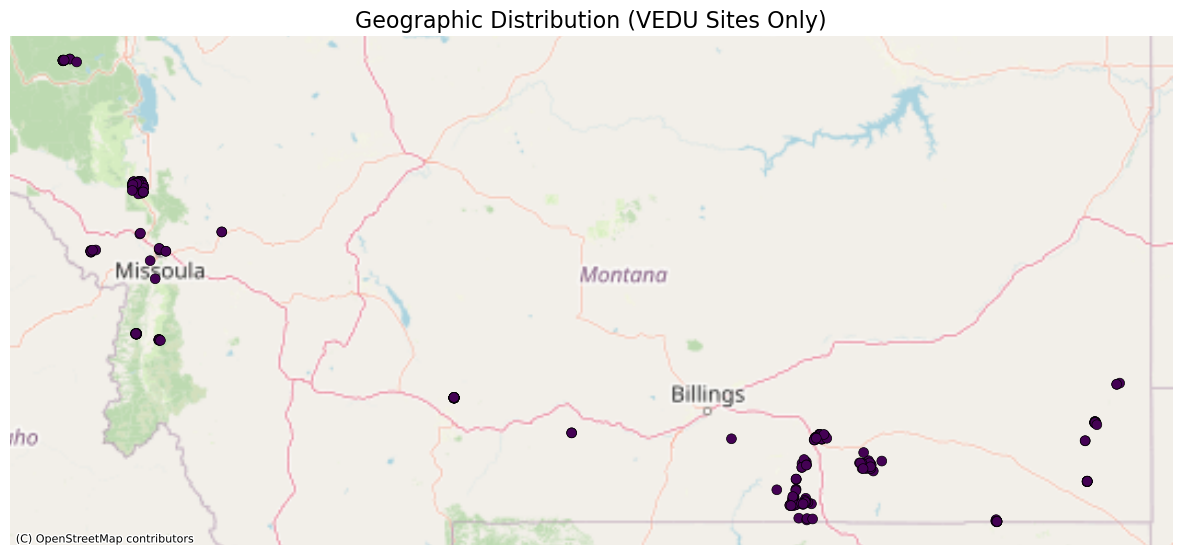

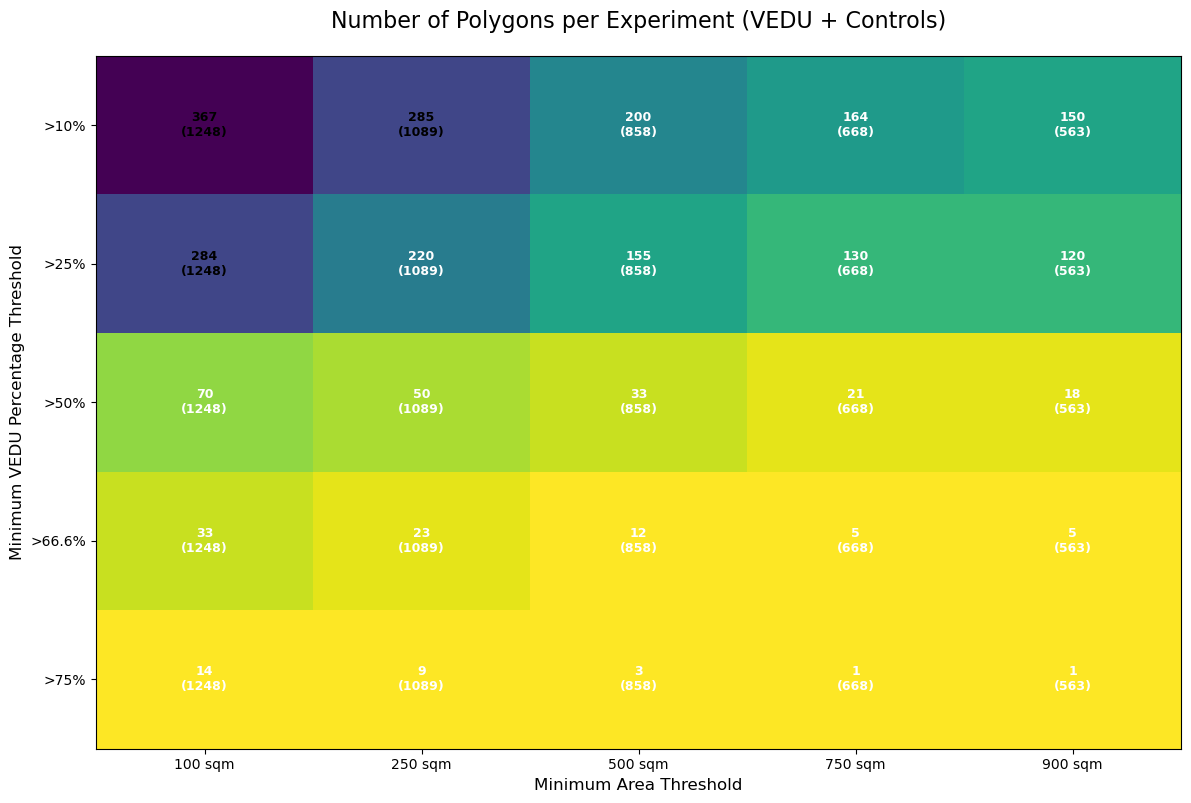

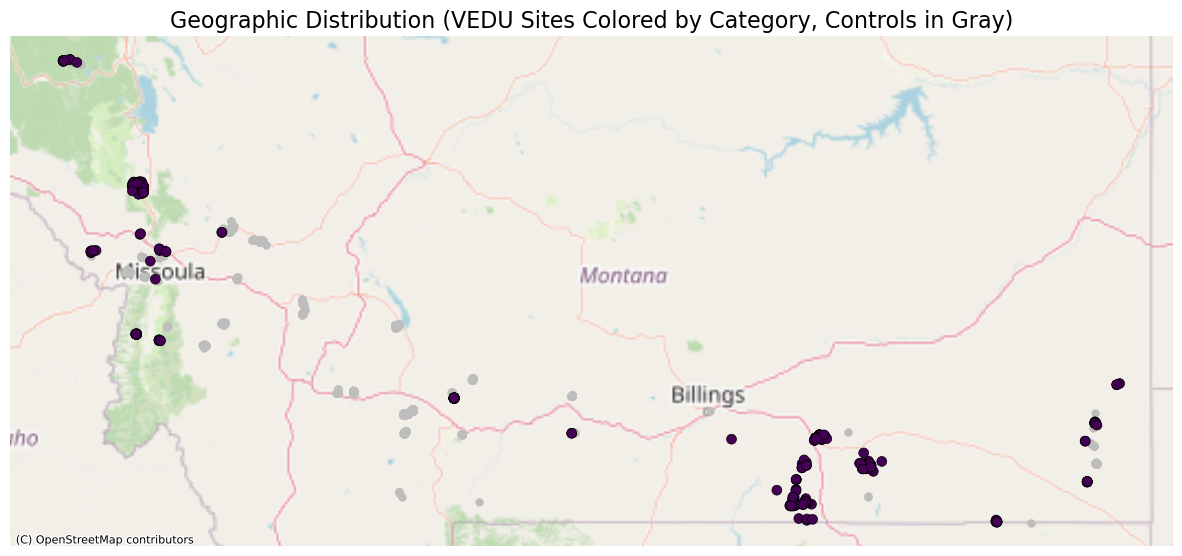

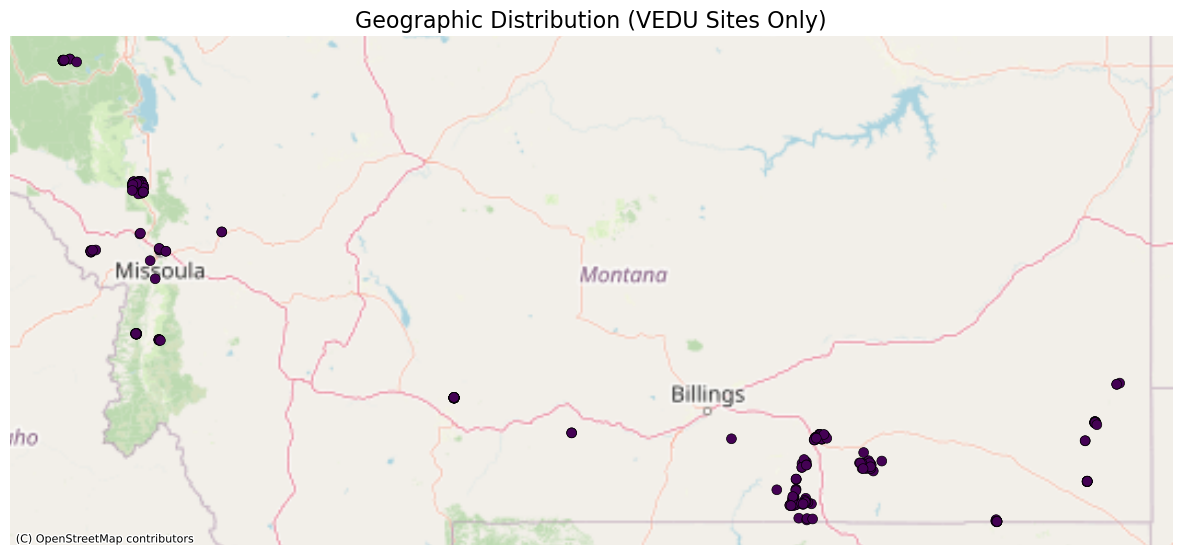

In [6]:
# =================================================================================
# --- STANDALONE VISUALIZATION: Detailed Categorical Plots & Maps ---
# =================================================================================

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import contextily as cx

def create_all_final_plots(
    experimental_sets: dict,
    percent_thresholds: list,
    area_thresholds: list
):
    """
    Generates three final plots:
    1. A categorical heatmap showing the breakdown of VEDU vs. Control sites.
    2. A map showing all unique sites (VEDU colored, Controls gray).
    3. A map showing only the VEDU sites, colored by their most restrictive category.
    """
    print("\n--- Generating Final Comparison Plots ---")
    
    # --- Part 1: Create a consistent color map for all VEDU categories ---
    # The color will be based on the number of VEDU SITES ONLY to show a gradient of restrictiveness.
    vedu_counts = [len(gdf[gdf['is_vedu_present'] == 1]) for gdf in experimental_sets.values()]
    norm = plt.Normalize(vmin=min(vedu_counts), vmax=max(vedu_counts))
    # Using a reversed colormap so more restrictive categories (fewer polygons) are brighter
    colors = plt.cm.get_cmap('viridis_r', 25) 
    
    color_map = {}
    i = 0
    # We sort to ensure a consistent color progression in the map and heatmap
    for percent in sorted(percent_thresholds):
        for area in sorted(area_thresholds):
            name = f"percent_{percent}_area_{area}"
            vedu_count = len(experimental_sets[name][experimental_sets[name]['is_vedu_present'] == 1])
            color_map[name] = colors(norm(vedu_count))
            i += 1
    print("✅ Color map created for VEDU categories.")

    # --- Part 2: Create the Categorical Heatmap ---
    print("Generating detailed categorical heatmap...")
    heatmap_fig, ax1 = plt.subplots(figsize=(14, 9))
    ax1.set_title("Number of Polygons per Experiment (VEDU + Controls)", fontsize=16, pad=20)

    for i, percent in enumerate(sorted(percent_thresholds)):
        for j, area in enumerate(sorted(area_thresholds)):
            exp_name = f"percent_{percent}_area_{area}"
            exp_gdf = experimental_sets[exp_name]
            vedu_count = len(exp_gdf[exp_gdf['is_vedu_present'] == 1])
            control_count = len(exp_gdf[exp_gdf['is_vedu_present'] == 0])
            text_label = f"{vedu_count}\n({control_count})"
            
            ax1.add_patch(plt.Rectangle((j, i), 1, 1, facecolor=color_map[exp_name]))
            text_color = "black" if norm(vedu_count) > 0.6 else "white"
            ax1.text(j + 0.5, i + 0.5, text_label, ha="center", va="center", color=text_color, fontsize=9, weight='bold')

    ax1.set_xlim(0, len(area_thresholds)); ax1.set_ylim(0, len(percent_thresholds))
    ax1.set_xticks(np.arange(len(area_thresholds)) + 0.5, labels=[f"{a} sqm" for a in sorted(area_thresholds)])
    ax1.set_yticks(np.arange(len(percent_thresholds)) + 0.5, labels=[f">{p}%" for p in sorted(percent_thresholds)])
    ax1.set_xlabel("Minimum Area Threshold", fontsize=12); ax1.set_ylabel("Minimum VEDU Percentage Threshold", fontsize=12)
    ax1.invert_yaxis()

    # --- Part 3: Prepare the data for mapping ---
    all_polygons_list = [gdf for gdf in experimental_sets.values() if not gdf.empty]
    if not all_polygons_list: return heatmap_fig, None, None
        
    master_gdf = pd.concat(all_polygons_list, ignore_index=True)
    unique_polygons_gdf = master_gdf.drop_duplicates(subset=['global_id']).copy()
    
    # Determine the single "best" (most restrictive) category for each polygon
    unique_polygons_gdf['best_category'] = 'control_site'
    for percent in sorted(percent_thresholds, reverse=True):
        for area in sorted(area_thresholds, reverse=True):
            exp_name = f"percent_{percent}_area_{area}"
            exp_gdf = experimental_sets[exp_name]
            unique_polygons_gdf.loc[unique_polygons_gdf['global_id'].isin(exp_gdf[exp_gdf['is_vedu_present']==1]['global_id']),'best_category'] = exp_name
    
    # Assign colors
    control_color = '#BDBDBD' # A neutral gray for controls
    unique_polygons_gdf['color'] = unique_polygons_gdf['best_category'].map(color_map).fillna(control_color)

    # --- Part 4: Create Map 1 (VEDU + Controls) ---
    print("Generating geospatial map with all sites...")
    points_all = unique_polygons_gdf.copy()
    points_all['geometry'] = points_all['geometry'].centroid
    points_all_web = points_all.to_crs(epsg=3857)
    
    map_fig_all, ax2 = plt.subplots(1, 1, figsize=(15, 12))
    points_all_web[points_all_web['best_category']=='control_site'].plot(ax=ax2, color=control_color, markersize=25, label='Control')
    points_all_web[points_all_web['best_category']!='control_site'].plot(ax=ax2, color=points_all_web['color'], markersize=50, edgecolor='black', linewidth=0.5)
    cx.add_basemap(ax2, source=cx.providers.OpenStreetMap.Mapnik)
    ax2.set_title("Geographic Distribution (VEDU Sites Colored by Category, Controls in Gray)", fontsize=16)
    ax2.set_axis_off()

    # --- Part 5: Create Map 2 (VEDU Only) ---
    print("Generating geospatial map with VEDU sites only...")
    points_vedu_only = unique_polygons_gdf[unique_polygons_gdf['is_vedu_present'] == 1].copy()
    if not points_vedu_only.empty:
        points_vedu_only['geometry'] = points_vedu_only['geometry'].centroid
        points_vedu_web = points_vedu_only.to_crs(epsg=3857)
        map_fig_vedu, ax3 = plt.subplots(1, 1, figsize=(15, 12))
        points_vedu_web.plot(ax=ax3, color=points_vedu_web['color'], markersize=50, edgecolor='black', linewidth=0.5)
        cx.add_basemap(ax3, source=cx.providers.OpenStreetMap.Mapnik)
        ax3.set_title("Geographic Distribution (VEDU Sites Only)", fontsize=16)
        ax3.set_axis_off()
    else:
        map_fig_vedu = None

    print("✅ All three figures created successfully.")
    return heatmap_fig, map_fig_all, map_fig_vedu

# --- EXECUTION ---
heatmap_figure, map_all_sites, map_vedu_only = create_all_final_plots(
    experimental_sets=experimental_sets,
    percent_thresholds=percent_variations,
    area_thresholds=area_variations
)

# --- DISPLAY PLOTS ---
print("\nDisplaying Detailed Categorical Heatmap (Legend):")
if heatmap_figure:
    display(heatmap_figure)

print("\nDisplaying Geospatial Map (VEDU Sites Colored, Controls in Gray):")
if map_all_sites:
    display(map_all_sites)
    
print("\nDisplaying Geospatial Map (VEDU Sites Only):")
if map_vedu_only:
    display(map_vedu_only)

# only touch from here down

# VEDU pipeline runner (cheatgrass codebase)
Refreshed cells below use the ventenata polygons and the shared pipeline helpers.


In [ ]:
import os, sys
from pathlib import Path

NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR.parent
sys.path.insert(0, str(NB_DIR))
sys.path.insert(0, str(REPO_ROOT))

VEDU_INPUT = Path('/home/rbielski/SAL_Git_Projects/Ventenata/Ventenata_Files/merge2324.shp')
os.environ['CHEATGRASS_INPUT_PATH'] = str(VEDU_INPUT)

print(f'Using VEDU input: {VEDU_INPUT}')
print(f'Notebook dir: {NB_DIR}')


In [ ]:
from cheatgrass_pipeline_but_vedu import (
    generate_experimental_datasets,
    PERCENT_VARIATIONS,
    AREA_VARIATIONS,
    TARGET_CRS,
)

exp_sets, final_test_set = generate_experimental_datasets(
    filepath=os.environ['CHEATGRASS_INPUT_PATH'],
    percent_thresholds=PERCENT_VARIATIONS,
    area_thresholds=AREA_VARIATIONS,
    target_crs=TARGET_CRS,
    include_controls=False,
)

print(f'Generated {len(exp_sets)} experimental sets')
for key, df in exp_sets.items():
    print(f'  {key}: {len(df)} rows')
print(f'Final test set rows: {len(final_test_set)}')
